In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy 
from scipy.stats import gaussian_kde
import astropy.units as u
from astropy.constants import M_sun
from astropy.constants import c
from astropy.constants import L_sun
import astropy.cosmology.units as cu
from astropy.cosmology import Planck18 as cosmo
from astropy.constants import L_sun
L_sun_eps = L_sun.cgs.value


(1470.0, 1530.0)

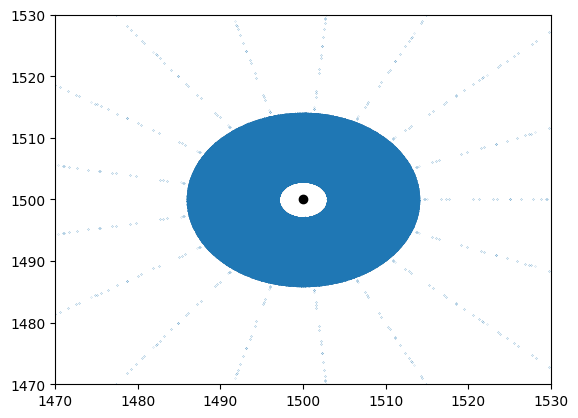

In [2]:
import sys
#sys.path.insert(0, '/mnt/home/skoudmani/for_kasar/python_scripts/')
sys.path.insert(0, '/soft/python3/usr/local/lib64/python3.9/site-packages') #import default cluster packages
sys.path.insert(0, '/beegfs/general/skoudmani/students/kasar/python/') #import custom packages
import read_snap_files as rsf
snapshot_path = '/beegfs/general/kprofit/binary_tests/ic_gen' 
snap_name = rsf.get_snap_filename(snapshot_path, 0, snap_prefix='ics_single_bh_3_hydrcgm1')
gas_coords = rsf.get_snap_data(snap_name, 0, 'Coordinates')
masses = rsf.get_snap_data(snap_name, 0, 'Masses')
BH_coords = rsf.get_snap_data(snap_name, 5, 'Coordinates')
BH_masses = rsf.get_snap_data(snap_name, 5, 'Masses')

x_coords = gas_coords[:,0]
y_coords = gas_coords[:,1] 
z_coords = gas_coords[:,2]



BH_x_coords = BH_coords[:,0]
BH_y_coords = BH_coords[:,1]

com = np.average(BH_coords,weights=BH_masses,axis=0) #calculate center of mass
gas_adj = gas_coords - com


plt.scatter(x_coords,y_coords, s=0.01)
plt.scatter(BH_x_coords,BH_y_coords, color = 'black')
plt.xlim(1470,1530)
plt.ylim(1470,1530)

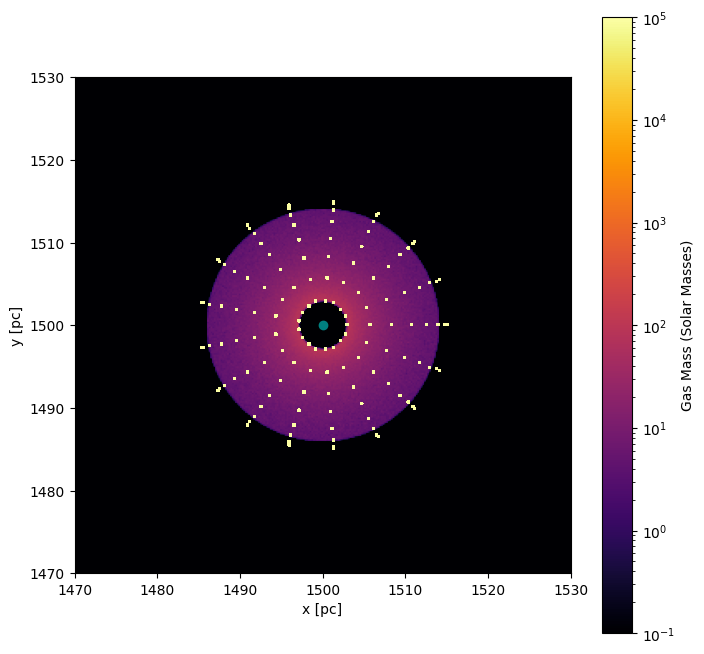

In [3]:
from matplotlib.colors import LogNorm

x_coords = gas_coords[:,0]
y_coords = gas_coords[:,1] 

BH_x_coords = BH_coords[:,0]
BH_y_coords = BH_coords[:,1]

nbins = 300
x_edges = np.linspace(1470,1530, nbins+1)
y_edges = np.linspace(1470,1530, nbins+1)

mass_max = 1.0       # choose an appropriate cutoff
good = masses < mass_max

#image, _, _ = np.histogram2d(x_coords[good], y_coords[good], bins=[x_edges, y_edges], weights=masses[good])
image, _, _ = np.histogram2d(x_coords, y_coords, bins=[x_edges, y_edges], weights=masses)
image[image <= 0] = 1e-1  # Adjust this floor if needed
#image[image >= 0] = 1e5  # Adjust this floor if needed

plt.figure(figsize=(8, 8))
plt.imshow(image.T, origin='lower', extent=[1470, 1530, 1470, 1530], cmap='inferno', norm=LogNorm(vmin=1e-1, vmax=1e5))
plt.colorbar(label="Gas Mass (Solar Masses)")
plt.scatter(BH_x_coords,BH_y_coords, color = 'teal')
plt.xlabel("x [pc]")
plt.ylabel('y [pc]')

#plt.savefig("singleBH_2D_hist_mpl.png", bbox_inches="tight",dpi=800)
plt.show()

In [11]:
import sys
#sys.path.insert(0, '/mnt/home/skoudmani/for_kasar/python_scripts/')
sys.path.insert(0, '/soft/python3/usr/local/lib64/python3.9/site-packages') #import default cluster packages
sys.path.insert(0, '/beegfs/general/skoudmani/students/kasar/python/') #import custom packages
import read_snap_files as rsf
snapshot_path = '/beegfs/general/kprofit/binary_tests/ic_gen' 
snap_name = rsf.get_snap_filename(snapshot_path, 0, snap_prefix='ics_single_bh_3_hydrcgm_mod')
gas_coords = rsf.get_snap_data(snap_name, 0, 'Coordinates')
masses = rsf.get_snap_data(snap_name, 0, 'Masses')
BH_coords = rsf.get_snap_data(snap_name, 5, 'Coordinates')
BH_masses = rsf.get_snap_data(snap_name, 5, 'Masses')

x_coords = gas_coords[:,0]
y_coords = gas_coords[:,1] 
z_coords = gas_coords[:,2]



BH_x_coords = BH_coords[:,0]
BH_y_coords = BH_coords[:,1]

com = np.average(BH_coords,weights=BH_masses,axis=0) #calculate center of mass
gas_adj = gas_coords - com

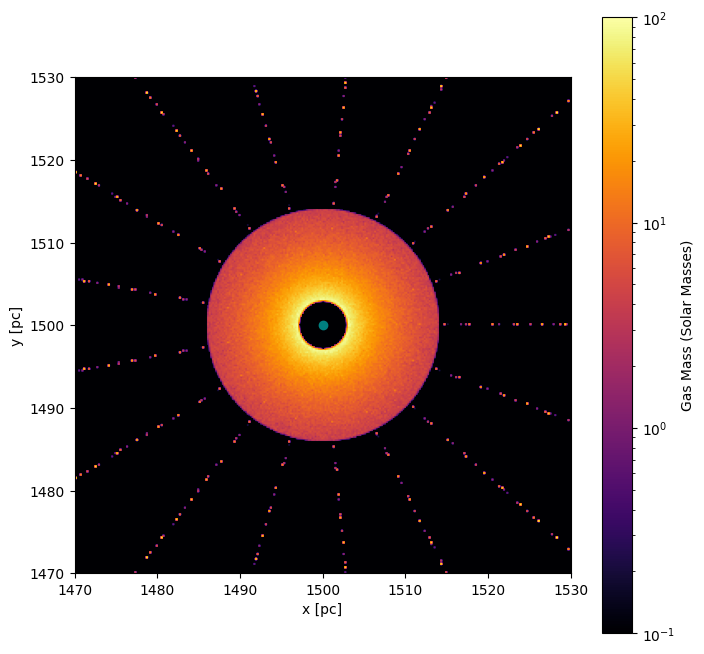

In [15]:
from matplotlib.colors import LogNorm

x_coords = gas_coords[:,0]
y_coords = gas_coords[:,1] 

BH_x_coords = BH_coords[:,0]
BH_y_coords = BH_coords[:,1]

nbins = 300
x_edges = np.linspace(1470,1530, nbins+1)
y_edges = np.linspace(1470,1530, nbins+1)

mass_max = 1.0       # choose an appropriate cutoff
good = masses < mass_max

#image, _, _ = np.histogram2d(x_coords[good], y_coords[good], bins=[x_edges, y_edges], weights=masses[good])
image, _, _ = np.histogram2d(x_coords, y_coords, bins=[x_edges, y_edges], weights=masses)
image[image <= 0] = 1e-1  # Adjust this floor if needed
#image[image >= 0] = 1e5  # Adjust this floor if needed

plt.figure(figsize=(8, 8))
plt.imshow(image.T, origin='lower', extent=[1470, 1530, 1470, 1530], cmap='inferno', norm=LogNorm(vmin=1e-1, vmax=1e2))
plt.colorbar(label="Gas Mass (Solar Masses)")
plt.scatter(BH_x_coords,BH_y_coords, color = 'teal')
plt.xlabel("x [pc]")
plt.ylabel('y [pc]')

#plt.savefig("singleBH_2D_hist_mpl.png", bbox_inches="tight",dpi=800)
plt.show()

In [6]:
print(masses.min(), masses.max())
print(np.unique(masses[:20]))

0.10201146123628484 5747.99000912845
[0.10208144 0.10705324 0.11648152 0.11869572 0.1257579  0.12584388
 0.12649943 0.12677027 0.13932813 0.14395629 0.16326337 0.18393592
 0.20634868 0.21733422 0.22342311 0.22732004 0.30320605 0.3394959
 0.34281993 0.42976939]


In [7]:
print("Image min:", image.min())
print("Image max:", image.max())
print("Nonzero min:", image[image > 0].min())
print("Median:", np.median(image[image > 0]))
print("99th percentile:", np.percentile(image[image > 0], 99))
print("Fraction empty:", np.mean(image == 0))

Image min: 0.1
Image max: 2039185.9587500114
Nonzero min: 0.1
Median: 0.1
99th percentile: 41.37497942239518
Fraction empty: 0.0


In [8]:
print(masses.dtype)
print(masses.shape)
print(masses[:10])
print(np.percentile(masses, [0, 50, 90, 99, 99.9, 100]))

float64
(1033637,)
[0.22732004 0.11648152 0.16326337 0.18393592 0.10705324 0.20634868
 0.21733422 0.3394959  0.42976939 0.1257579 ]
[1.02011461e-01 1.71526390e-01 3.78547886e-01 1.43702821e+03
 3.47720037e+03 5.74799001e+03]


In [9]:
print(BH_masses)

[2000000.]


In [10]:
mask = masses > 1

print("Particles with mass > 1:", np.sum(mask))
print(masses[mask])

Particles with mass > 1: 33059
[1.97342392e+00 1.97342392e+00 1.97342392e+00 ... 5.74799001e+03
 5.74799001e+03 5.74799001e+03]
